# Decision Trees Classification Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a decision tree classification model from scratch using one of the datasets below.

You've seen the full process in the Iris class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these datasets. Each has a different classification target:

| Dataset | How to Load | What You Predict | Rows | Features | Classes | Difficulty |
|---------|-------------|------------------|------|----------|---------|------------|
| **Palmer Penguins** | `sns.load_dataset('penguins')` | Penguin species | 344 | 4 numeric | 3 | Easy |
| **Wine Recognition** | `load_wine(as_frame=True)` | Wine cultivar (vineyard) | 178 | 13 numeric | 3 | Easy-Medium |
| **Breast Cancer Wisconsin** | `load_breast_cancer(as_frame=True)` | Malignant vs Benign | 569 | 30 numeric | 2 | Medium |

See the **Dataset Guide** for full descriptions of each one.

**Note:** Wine and Breast Cancer are built into scikit-learn — no internet needed. Palmer Penguins is in seaborn.

---

### The Steps (follow this structure)

1. Import libraries (no installs needed!)
2. Load your chosen dataset
3. Explore: check shape, columns, missing values, and clean the data
4. Drop any non-numeric columns (if your dataset has them)
5. Make at least ONE scatter plot — pick two features and color by class
6. Train/test split (80/20)
7. Build and train a DecisionTreeClassifier (set max_depth=3 to start)
8. Evaluate: print accuracy and the classification report
9. Show the confusion matrix as a heatmap
10. Visualize the tree using plot_tree
11. Show feature importance as a bar chart
12. Try changing max_depth and compare accuracy

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- LOAD (pick the one that matches your dataset) ---

# Palmer Penguins (from seaborn):
df = sns.load_dataset('penguins')

# Wine Recognition (from sklearn — no internet needed):
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
df = X.copy()
df['cultivar'] = y

# Breast Cancer Wisconsin (from sklearn — no internet needed):
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
df = X.copy()
df['diagnosis'] = y

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- DROP NON-NUMERIC COLUMNS (if needed) ---
df = df.drop(columns=['col1', 'col2'])   # drop text columns

# --- SET UP X AND y ---
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT (color by class) ---
plt.figure(figsize=(8, 6))
for className in y.unique():
    mask = y == className
    plt.scatter(X.loc[mask, 'feature1'], X.loc[mask, 'feature2'],
                label=className, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Your Title')
plt.legend()
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
treeModel = DecisionTreeClassifier(max_depth=3, random_state=42)
treeModel.fit(X_train, y_train)

# --- EVALUATE ---
predictions = treeModel.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2%}')
print(classification_report(y_test, predictions))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- TREE VISUALIZATION ---
plt.figure(figsize=(16, 8))
plot_tree(treeModel, feature_names=list(X.columns),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree')
plt.show()

# --- FEATURE IMPORTANCE ---
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=False)
plt.barh(importanceDf['Feature'], importanceDf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

# --- EXPERIMENT WITH DEPTH ---
for depth in [2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f'max_depth={depth}: accuracy={acc:.2%}')
```

## Step 1: Install + Import Libraries

In [ ]:
# No extra installs needed!
# Palmer Penguins is in seaborn, Wine and Breast Cancer are in sklearn
print("All datasets are built-in — no pip install needed!")

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Load Your Dataset

**Palmer Penguins:** `sns.load_dataset('penguins')`

**Wine Recognition:** `from sklearn.datasets import load_wine` then `wine = load_wine(as_frame=True)`

**Breast Cancer:** `from sklearn.datasets import load_breast_cancer` then `cancer = load_breast_cancer(as_frame=True)`

In [10]:
penguins = sns.load_dataset("penguins")
penguins = penguins.dropna()

penguins = penguins[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species"
]]


## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values. If there are missing values, drop them.

In [15]:
penguins.info()
penguins.describe()
penguins.isna().sum()
penguins.head()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
 4   species            333 non-null    object 
dtypes: float64(4), object(1)
memory usage: 15.6+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
4,36.7,19.3,193.0,3450.0,Adelie
5,39.3,20.6,190.0,3650.0,Adelie


## Step 4: Clean the Data

Drop any non-numeric columns (text columns like 'island', 'sex', etc.) since the tree can't use them. Then set up your X (features) and y (target) variables.

In [16]:
penguins = penguins.dropna()
penguins = penguins[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species"
]]
penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
4,36.7,19.3,193.0,3450.0,Adelie
5,39.3,20.6,190.0,3650.0,Adelie


## Step 5: Scatter Plot

Pick two features and make a scatter plot colored by class. This helps you see whether the classes form natural clusters or overlap a lot.

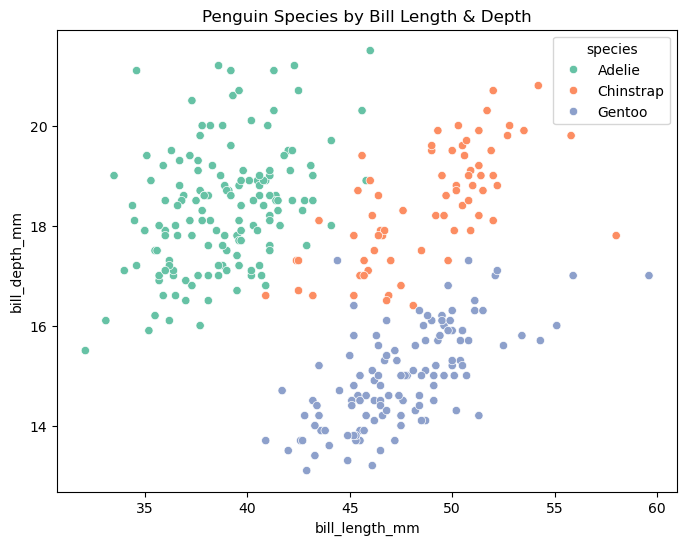

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette="Set2"
)
plt.title("Penguin Species by Bill Length & Depth")
plt.show()

## Step 6: Train/Test Split

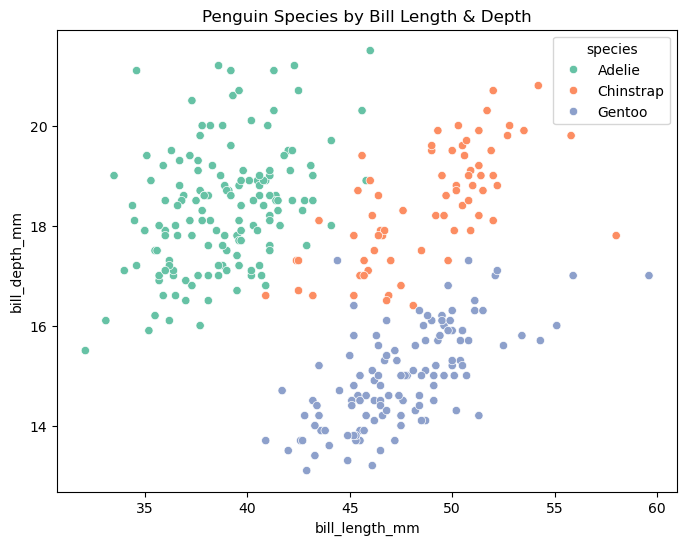

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette="Set2"
)
plt.title("Penguin Species by Bill Length & Depth")
plt.show()

## Step 7: Build and Train the Decision Tree

Use `DecisionTreeClassifier(max_depth=3, random_state=42)` to start. We'll experiment with depth later.

In [19]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

## Step 8: Evaluate

Print the accuracy and the full classification report. The report shows precision, recall, and f1-score for each class.

In [20]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9850746268656716

Classification Report:
               precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        31
   Chinstrap       1.00      0.92      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.99      0.97      0.98        67
weighted avg       0.99      0.99      0.98        67



## Step 9: Confusion Matrix

Show the confusion matrix as a heatmap. The diagonal shows correct predictions. Off-diagonal shows mistakes — look at WHERE the model gets confused.

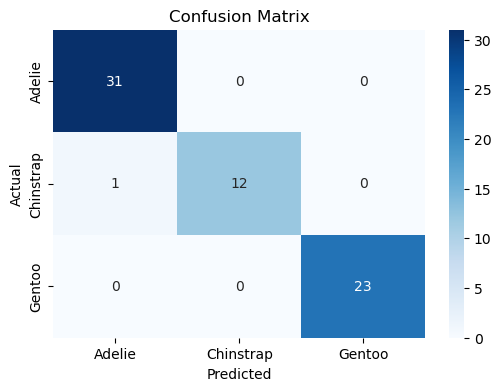

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 10: Visualize the Tree

Use `plot_tree` to see the actual decision rules. Read through it — can you follow the yes/no questions from root to leaf?

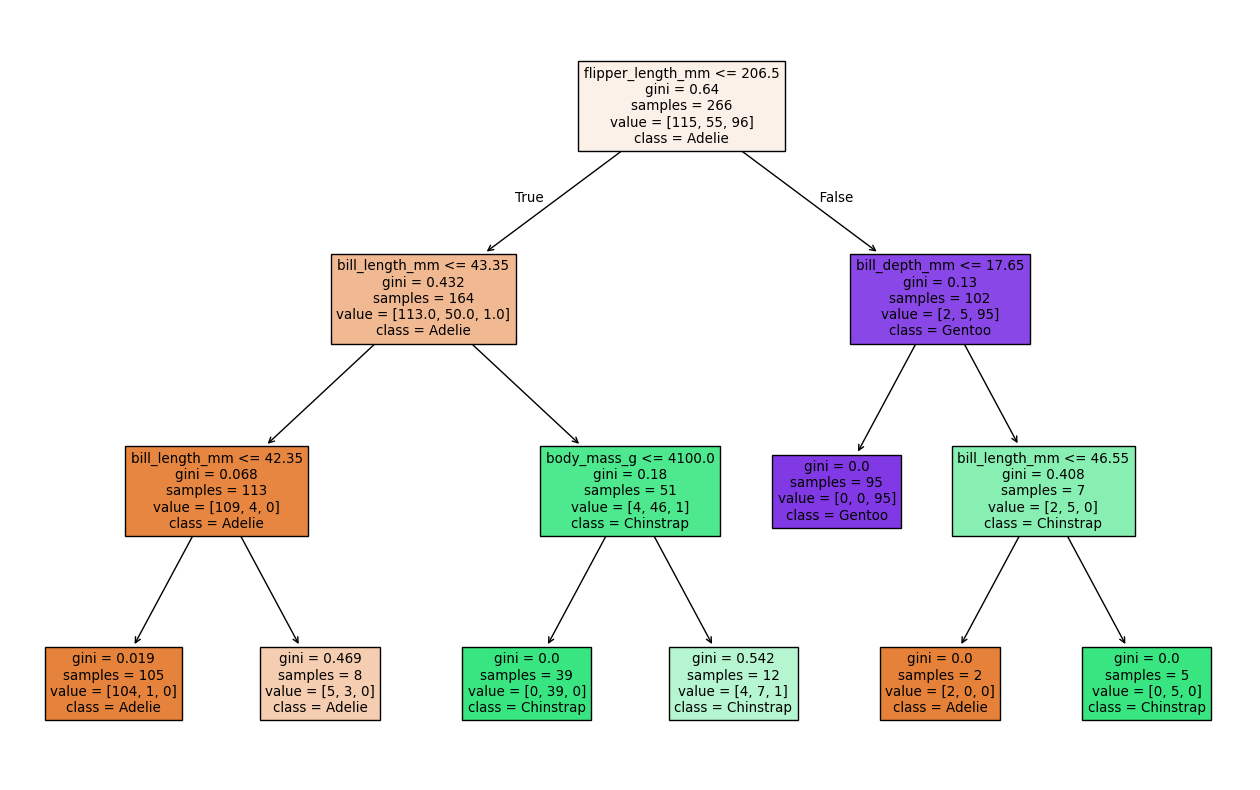

In [22]:
plt.figure(figsize=(16,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)
plt.show()

## Step 11: Feature Importance

Show which features the tree uses most. Does this match what you expected from your scatter plot?

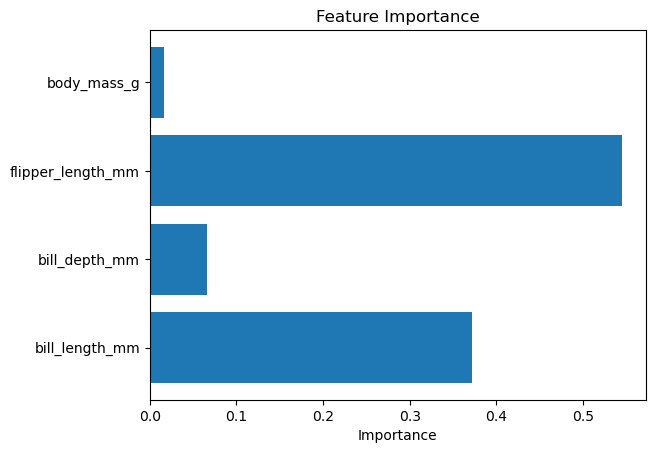

In [23]:
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

## Step 12: Experiment with max_depth

Try different values of `max_depth` (2, 3, 5, 10, and None for unlimited). Print the accuracy for each. What happens when the tree gets too deep? What happens when it's too shallow?

In [24]:
depth_values = [2, 3, 5, 10, None]
for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"max_depth={depth} → accuracy={acc:.3f}")

max_depth=2 → accuracy=0.985
max_depth=3 → accuracy=0.985
max_depth=5 → accuracy=1.000
max_depth=10 → accuracy=1.000
max_depth=None → accuracy=1.000


## Reflection (answer in this cell)

1. What dataset did you choose and why? 
2. What was your accuracy? Is that good or bad for your dataset?
3. Look at your confusion matrix — where does the model make the most mistakes? Why do you think that is?
4. Which feature was the most important? Does that make real-world sense?
5. What happened when you changed max_depth? Was there a "sweet spot"?
6. How does building a classification model compare to the regression model you built before? What's similar? What's different?